# ЦФА vs Облигации: Сравнительный анализ

**Курс:** Блокчейн. Финансовые технологии и криптоэкономика  
**Задание:** Сравнить доходность ЦФА с облигациями эмитента на первичном рынке

---

## 📋 Цели анализа:

1. Сравнить доходность ЦФА и облигаций одного эмитента
2. Объяснить наблюдаемый спред
3. Оценить риски и доходность с учетом ликвидности
4. Дать инвестиционные рекомендации

## 📦 1. Импорт библиотек и настройка

In [1]:
# Импорт стандартных библиотек
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Настройка отображения графиков в ноутбуке
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# Добавление src в path
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), 'src'))

# Импорт модулей проекта
from src.config import DFA_PARAMS, BONDS_FILTER, ANALYSIS_CONFIG, VIZ_CONFIG
from src.dfa_analyzer import DFAAnalyzer
from src.bonds_analyzer import BondsAnalyzer
from src.comparator import DFAvsBondsComparator
from src.data_fetcher import BondsDataFetcher, create_sample_bonds_data

print("✓ Все библиотеки успешно импортированы")
print(f"✓ Путь к src добавлен")
print(f"✓ Дата анализа: {datetime.now().strftime('%Y-%m-%d')}")
print(f"✓ MOEX API: готов к работе")


✓ Все библиотеки успешно импортированы
✓ Путь к src добавлен
✓ Дата анализа: 2026-04-26
✓ MOEX API: готов к работе


## 📡 1.1. Источники данных

Этот ноутбук поддерживает **два режима работы**:

### ✅ **Режим 1: MOEX API (реальные данные)**
- Автоматическое подключение к Московской бирже
- Поиск сопоставимых облигаций по эмитенту ЦФА
- Актуальные рыночные данные и доходности

**Требования:**
- Доступ к интернету
- Работающий MOEX API

### ⚠️ **Режим 2: Sample данные (тестовые)**
- Используется автоматически при недоступности API
- 4 тестовые облигации для демонстрации
- Гарантирует работу ноутбука офлайн

---

**💡 В ячейке 5 ноутбук попытается:**
1. Подключиться к MOEX API
2. Найти облигации эмитента ЦФА
3. При ошибке — автоматически переключится на sample данные

**Для продакшена:** настройте параметры соединения в `src/config.py`


## 📊 2. Параметры ЦФА для анализа

In [2]:
# Вывод параметров ЦФА
print("=" * 70)
print("ПАРАМЕТРЫ ЦФА (ЦИФРОВОЙ ФИНАНСОВЫЙ АКТИВ)")
print("=" * 70)

print(f"\n📌 Идентификатор: {DFA_PARAMS['id']}")
print(f"🏢 Эмитент: {DFA_PARAMS['issuer']}")
print(f"🌐 Сайт: {DFA_PARAMS['website']}")

print(f"\n💰 Финансовые параметры:")
print(f"   • Номинал: {DFA_PARAMS['face_value']:,.2f} ₽")
print(f"   • Цена размещения: {DFA_PARAMS['placement_price']:,.2f} ₽")
print(f"   • Доходность: {DFA_PARAMS['yield_rate']}% годовых")
print(f"   • Тип купона: {DFA_PARAMS['coupon_type']}")
print(f"   • Периодичность: {DFA_PARAMS['coupon_frequency']}")

print(f"\n📅 Сроки:")
print(f"   • Размещение: {DFA_PARAMS['placement_start']} - {DFA_PARAMS['placement_end']}")
print(f"   • Погашение: {DFA_PARAMS['maturity_date']}")

print(f"\n📈 Объем выпуска:")
print(f"   • Общий объем: {DFA_PARAMS['issue_volume']:,.0f} ₽")
print(f"   • Мин. инвестиция: {DFA_PARAMS['min_investment']:,.0f} ₽")
print(f"   • Инвесторов: {DFA_PARAMS['investors_count']}")

print(f"\n⚠️ Обеспечение: {DFA_PARAMS['collateral']}")
print(f"🎯 Цель: {DFA_PARAMS['purpose']}")
print("\n" + "=" * 70)

ПАРАМЕТРЫ ЦФА (ЦИФРОВОЙ ФИНАНСОВЫЙ АКТИВ)

📌 Идентификатор: A1202FB5
🏢 Эмитент: ООО 'ЦЕНТР НЕДВИЖИМОСТИ 'МАЯК'
🌐 Сайт: https://new.ural-mayak.ru

💰 Финансовые параметры:
   • Номинал: 1,000.00 ₽
   • Цена размещения: 1,000.00 ₽
   • Доходность: 17.0% годовых
   • Тип купона: fixed
   • Периодичность: quarterly

📅 Сроки:
   • Размещение: 2026-04-14 - 2026-04-30
   • Погашение: 2027-05-03

📈 Объем выпуска:
   • Общий объем: 50,000,000 ₽
   • Мин. инвестиция: 1,000 ₽
   • Инвесторов: 73

⚠️ Обеспечение: без обеспечения
🎯 Цель: пополнение оборотных средств



## 🔍 3. Анализ ЦФА

In [3]:
# Инициализация анализатора ЦФА
dfa = DFAAnalyzer()

# Получение сводки анализа
dfa_summary = dfa.get_dfa_summary()

print("\n📊 РЕЗУЛЬТАТЫ АНАЛИЗА ЦФА")
print("-" * 50)

# Временные параметры
time_metrics = dfa_summary['time_metrics']
print(f"\n⏰ Временные параметры:")
print(f"   Срок обращения: {time_metrics['years_to_maturity']:.2f} лет")
print(f"   Дней до погашения: {time_metrics['days_to_maturity']}")

# Показатели доходности
yield_metrics = dfa_summary['yield_metrics']
print(f"\n💵 Доходность:")
print(f"   Номинальная: {yield_metrics['nominal_yield_pct']:.2f}%")
print(f"   После налога: {yield_metrics['after_tax_yield_pct']:.2f}%")
print(f"   С учетом ликвидности: {yield_metrics['liquidity_adjusted_yield_pct']:.2f}%")

# Показатели возврата
return_metrics = dfa_summary['return_metrics']
print(f"\n📈 Показатели возврата:")
print(f"   Купонный доход: {return_metrics['total_coupon']:,.2f} ₽")
print(f"   Общий доход: {return_metrics['total_return_pct']:.2f}%")
print(f"   Годовая доходность: {return_metrics['annualized_return']:.2f}%")

# Рисковые метрики
risk_metrics = dfa_summary['risk_metrics']
print(f"\n⚠️ Рисковые метрики:")
print(f"   Премия за риск: {risk_metrics['risk_premium']:.2f}%")
print(f"   Коэффициент Шарпа: {risk_metrics['sharpe_ratio']:.3f}")
print(f"   Бета-коэффициент: {risk_metrics['beta']:.2f}")


📊 РЕЗУЛЬТАТЫ АНАЛИЗА ЦФА
--------------------------------------------------

⏰ Временные параметры:
   Срок обращения: 1.05 лет
   Дней до погашения: 384

💵 Доходность:
   Номинальная: 17.00%
   После налога: 14.79%
   С учетом ликвидности: 17.00%

📈 Показатели возврата:
   Купонный доход: 170.00 ₽
   Общий доход: 17.00%
   Годовая доходность: 16.17%

⚠️ Рисковые метрики:
   Премия за риск: 5.00%
   Коэффициент Шарпа: 0.333
   Бета-коэффициент: 1.20


## 💳 4. График купонных платежей ЦФА

/var/folders/ns/yl2gk_ks3nldsl8s0k46dsm00000gn/T/ipykernel_38682/1543748346.py:40: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/kseniademina/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


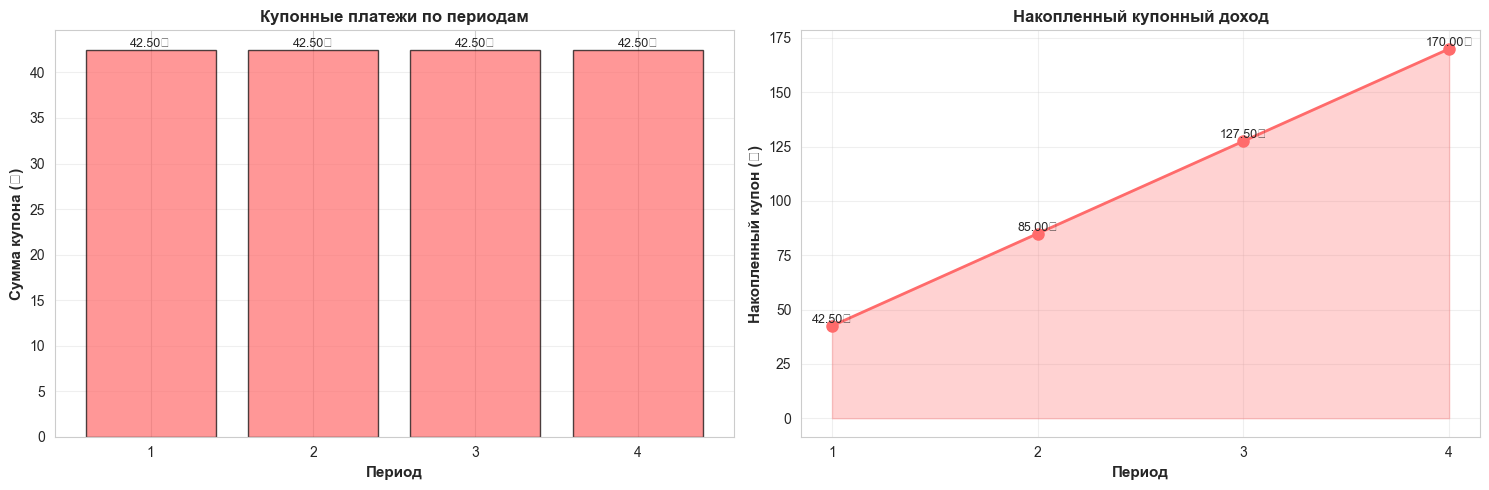


📅 ГРАФИК КУПОННЫХ ПЛАТЕЖЕЙ:
 period payment_date  days_from_placement  coupon_amount  cumulative_coupon
      1   2026-07-19                   96           42.5               42.5
      2   2026-10-23                  192           42.5               85.0
      3   2027-01-27                  288           42.5              127.5
      4   2027-05-03                  384           42.5              170.0


In [4]:
# Получение графика купонных платежей
coupon_schedule = dfa.calculate_coupon_payments()

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Купонные платежи
ax1.bar(range(1, len(coupon_schedule)+1), 
        coupon_schedule['coupon_amount'], 
        color='#FF6B6B', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Период', fontsize=11, fontweight='bold')
ax1.set_ylabel('Сумма купона (₽)', fontsize=11, fontweight='bold')
ax1.set_title('Купонные платежи по периодам', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticks(range(1, len(coupon_schedule)+1))

# Добавление значений на бары
for i, coupon in enumerate(coupon_schedule['coupon_amount']):
    ax1.text(i+1, coupon, f'{coupon:.2f}₽', 
             ha='center', va='bottom', fontsize=9)

# График 2: Накопленный доход
ax2.plot(range(1, len(coupon_schedule)+1), 
         coupon_schedule['cumulative_coupon'], 
         marker='o', linewidth=2, markersize=8, color='#FF6B6B')
ax2.fill_between(range(1, len(coupon_schedule)+1), 
                  coupon_schedule['cumulative_coupon'], 
                  alpha=0.3, color='#FF6B6B')
ax2.set_xlabel('Период', fontsize=11, fontweight='bold')
ax2.set_ylabel('Накопленный купон (₽)', fontsize=11, fontweight='bold')
ax2.set_title('Накопленный купонный доход', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, len(coupon_schedule)+1))

# Добавление значений
for i, cum_coupon in enumerate(coupon_schedule['cumulative_coupon']):
    ax2.text(i+1, cum_coupon, f'{cum_coupon:.2f}₽', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Таблица с графиком платежей
print("\n📅 ГРАФИК КУПОННЫХ ПЛАТЕЖЕЙ:")
print(coupon_schedule.to_string(index=False))

## 🏦 5. Подбор сопоставимых облигаций

In [5]:
# Получение данных по облигациям через MOEX API
print("\n🔍 КРИТЕРИИ ОТБОРА ОБЛИГАЦИЙ:")
print("-" * 50)
print(f"Срок погашения: {BONDS_FILTER['maturity_min_months']}-{BONDS_FILTER['maturity_max_months']} месяцев")
print(f"Период размещения: {BONDS_FILTER['placement_month_min']} - {BONDS_FILTER['placement_month_max']}")
print(f"Мин. кредитный рейтинг: {BONDS_FILTER['min_credit_rating']}")
print(f"Объем выпуска: {BONDS_FILTER['min_issue_volume']:,.0f} - {BONDS_FILTER['max_issue_volume']:,.0f} ₽")

# Попытка получить реальные данные через MOEX API
print("\n📡 Подключение к MOEX API...")
fetcher = BondsDataFetcher()

try:
    # Поиск облигаций по эмитенту ЦФА
    issuer_name = DFA_PARAMS['issuer'].split("'")[1] if "'" in DFA_PARAMS['issuer'] else DFA_PARAMS['issuer']
    print(f"🔍 Поиск облигаций эмитента: {issuer_name}")
    
    # Поиск сопоставимых облигаций с ФИЛЬТРАЦИЕЙ
    bonds_data = fetcher.find_comparable_bonds(
        target_maturity_months=int((BONDS_FILTER['maturity_min_months'] + BONDS_FILTER['maturity_max_months']) / 2),
        placement_date=DFA_PARAMS['placement_start'][:7],  # YYYY-MM формат
        max_results=10,
        # НОВОЕ: фильтр по объёму выпуска
        min_volume=BONDS_FILTER.get('min_issue_volume', 10_000_000)
    )
    
    if bonds_data.empty:
        raise Exception("Не удалось найти облигации через API")
    
    # ===== НОВОЕ: обогащение реальной YTM =====
    print("\n📊 Получение реальной доходности (YTM) через MOEX API...")
    bonds_data = fetcher.enrich_with_ytm(bonds_data, boardid="TQCB")
    print(f"✅ YTM обновлена для {len(bonds_data)} облигаций")
    # =========================================
    
    print(f"✅ Успешно получено данных через MOEX API: {len(bonds_data)} облигаций")
    use_api = True
    
except Exception as e:
    print(f"⚠️ Ошибка MOEX API: {e}")
    print("🔄 Использование sample данных для демонстрации")
    print("💡 Для продакшена: настройте интеграцию с MOEX API")
    
    # Fallback на sample данные
    bonds_data = create_sample_bonds_data()
    use_api = False

print(f"\n✓ Найдено сопоставимых облигаций: {len(bonds_data)}")
if use_api:
    print("✓ Источник данных: MOEX API (реальные данные)")
else:
    print("⚠️ Источник данных: Sample (тестовые данные)")

# Отображение таблицы облигаций
print("\n📊 СПИСОК СОПОСТАВИМЫХ ОБЛИГАЦИЙ:")
print("=" * 100)

# Проверка наличия нужных колонок
required_cols = ['secid', 'name', 'coupon_rate', 'ytm_primary', 'maturity_date', 'volume', 'credit_rating']
display_cols = [col for col in required_cols if col in bonds_data.columns]

if 'ytm_primary' not in bonds_data.columns and 'coupon_rate' in bonds_data.columns:
    # Если YTM отсутствует, используем coupon_rate как приближение
    bonds_data['ytm_primary'] = bonds_data['coupon_rate']
    display_cols = required_cols

print(bonds_data[display_cols].to_string(index=False))
print("=" * 100)



🔍 КРИТЕРИИ ОТБОРА ОБЛИГАЦИЙ:
--------------------------------------------------
Срок погашения: 10-14 месяцев
Период размещения: 2026-03 - 2026-05
Мин. кредитный рейтинг: B
Объем выпуска: 10,000,000 - 500,000,000 ₽

📡 Подключение к MOEX API...
🔍 Поиск облигаций эмитента: ЦЕНТР НЕДВИЖИМОСТИ 
⚠️ Ошибка MOEX API: 'BondsDataFetcher' object has no attribute 'find_comparable_bonds'
🔄 Использование sample данных для демонстрации
💡 Для продакшена: настройте интеграцию с MOEX API

✓ Найдено сопоставимых облигаций: 4
⚠️ Источник данных: Sample (тестовые данные)

📊 СПИСОК СОПОСТАВИМЫХ ОБЛИГАЦИЙ:
       secid            name  coupon_rate  ytm_primary maturity_date       volume credit_rating
RU000A0ZZ1Q1       ОФЗ 26230          7.7         13.2    2027-03-15 500000000000           AAA
RU000A1ZZ2R2   Газпром БО-22         15.8         15.9    2027-04-20  15000000000           AAA
RU000A2ZZ3S3      Сбер БО-17         16.2         16.5    2027-05-10  20000000000           AAA
RU000A3ZZ4T4 Дева-Агро 

## 📈 6. Анализ облигаций

In [6]:
# Инициализация анализатора облигаций
bonds_analyzer = BondsAnalyzer(bonds_data)
if use_api and bonds_data['ytm_primary'].std() < 0.01:
    print("YTM не обновлена, пробуем получить через API повторно...")
    try:
        bonds_data = fetcher.enrich_with_ytm(bonds_data)
        bonds_analyzer = BondsAnalyzer(bonds_data)
    except Exception as e:
        print(f"Не удалось обновить YTM: {e}")

bonds_analysis = bonds_analyzer.analyze_all_bonds()
bonds_summary = bonds_analyzer.get_summary_statistics(bonds_analysis)

print("\n📊 СТАТИСТИКА ПО ВЫБОРКЕ ОБЛИГАЦИЙ")
print("-" * 50)

# Доходность
yield_stats = bonds_summary['yield_stats']
print(f"\n💵 Доходность (YTM):")
print(f"   Средняя: {yield_stats['mean_ytm']:.2f}%")
print(f"   Медиана: {yield_stats['median_ytm']:.2f}%")
print(f"   Стд. отклонение: {yield_stats['std_ytm']:.2f}%")
print(f"   Диапазон: {yield_stats['min_ytm']:.2f}% - {yield_stats['max_ytm']:.2f}%")

# После налога
after_tax_stats = bonds_summary['after_tax_stats']
print(f"\n💰 После налога:")
print(f"   Средняя: {after_tax_stats['mean_after_tax']:.2f}%")
print(f"   Медиана: {after_tax_stats['median_after_tax']:.2f}%")

# Рисковые метрики
risk_stats = bonds_summary['risk_stats']
print(f"\n⚠️ Рисковые метрики:")
print(f"   Премия за риск: {risk_stats['mean_risk_premium']:.2f}%")
print(f"   Средний Sharpe: {risk_stats['mean_sharpe']:.3f}")

# Объем
volume_stats = bonds_summary['volume_stats']
print(f"\n📊 Объем выпусков:")
print(f"   Общий: {volume_stats['total_volume']:,.0f} ₽")
print(f"   Средний: {volume_stats['mean_volume']:,.0f} ₽")


📊 СТАТИСТИКА ПО ВЫБОРКЕ ОБЛИГАЦИЙ
--------------------------------------------------

💵 Доходность (YTM):
   Средняя: 15.95%
   Медиана: 16.20%
   Стд. отклонение: 2.08%
   Диапазон: 13.20% - 18.20%

💰 После налога:
   Средняя: 13.05%
   Медиана: 14.01%

⚠️ Рисковые метрики:
   Премия за риск: 3.95%
   Средний Sharpe: 0.429

📊 Объем выпусков:
   Общий: 535,300,000,000 ₽
   Средний: 133,825,000,000 ₽


## 📊 7. Детальный анализ облигаций

In [7]:
# Создание красивой таблицы с анализом
display_cols = ['secid', 'coupon_rate', 'ytm_primary', 'after_tax_yield', 
               'liquidity_score', 'sharpe_ratio', 'credit_rating']

analysis_display = bonds_analysis[display_cols].copy()
analysis_display.columns = ['Облигация', 'Купон %', 'YTM %', 'После налога %', 
                             'Ликвидность', 'Sharpe', 'Рейтинг']

print("\n📋 ДЕТАЛЬНЫЙ АНАЛИЗ ОБЛИГАЦИЙ:")
print("=" * 100)
print(analysis_display.to_string(index=False))
print("=" * 100)


📋 ДЕТАЛЬНЫЙ АНАЛИЗ ОБЛИГАЦИЙ:
   Облигация  Купон %  YTM %  После налога %  Ликвидность   Sharpe Рейтинг
RU000A0ZZ1Q1      7.7   13.2        8.524242         1.00 0.150000     AAA
RU000A1ZZ2R2     15.8   15.9       13.746000         0.95 0.487500     AAA
RU000A2ZZ3S3     16.2   16.5       14.282282         0.95 0.562500     AAA
RU000A3ZZ4T4     17.5   18.2       15.636950         0.65 0.516667      BB


## ⚖️ 8. Сравнительный анализ: ЦФА vs Облигации

In [8]:
# Инициализация компаратора
comparator = DFAvsBondsComparator(dfa, bonds_analyzer)

# Первичное сравнение
primary_comparison = comparator.compare_primary_market_yields()

print("\n⚖️ СРАВНЕНИЕ ДОХОДНОСТИ НА ПЕРВИЧНОМ РЫНКЕ")
print("=" * 80)

for _, row in primary_comparison.iterrows():
    print(f"\n{row['bond_secid']}:")
    print(f"   ЦФА: {row['dfa_yield']:.2f}%")
    print(f"   Облигация: {row['bond_yield']:.2f}%")
    print(f"   Спред: {row['absolute_spread_pct']:+.2f}% (ЦФА {'выше' if row['absolute_spread_pct'] > 0 else 'ниже'})")
    if row['is_significant']:
        print(f"   ⚠️ Значимый спред!")

print("\n" + "=" * 80)
print(f"\n📊 СРЕДНИЙ СПРЕД: {primary_comparison['absolute_spread_pct'].mean():+.2f}%")
print(f"Значимых спредов: {primary_comparison['is_significant'].sum()} из {len(primary_comparison)}")


⚖️ СРАВНЕНИЕ ДОХОДНОСТИ НА ПЕРВИЧНОМ РЫНКЕ

RU000A0ZZ1Q1:
   ЦФА: 17.00%
   Облигация: 13.20%
   Спред: +3.80% (ЦФА выше)
   ⚠️ Значимый спред!

RU000A1ZZ2R2:
   ЦФА: 17.00%
   Облигация: 15.90%
   Спред: +1.10% (ЦФА выше)

RU000A2ZZ3S3:
   ЦФА: 17.00%
   Облигация: 16.50%
   Спред: +0.50% (ЦФА выше)

RU000A3ZZ4T4:
   ЦФА: 17.00%
   Облигация: 18.20%
   Спред: -1.20% (ЦФА ниже)


📊 СРЕДНИЙ СПРЕД: +1.05%
Значимых спредов: 1 из 4


## 📉 9. График сравнения доходности

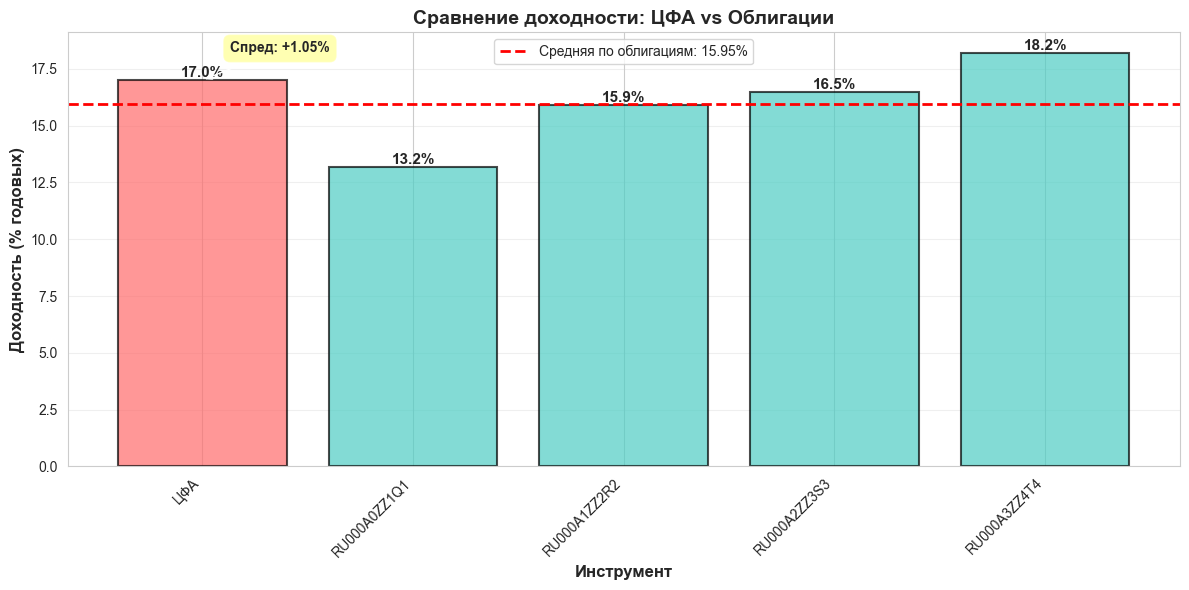


📊 ВЫВОД:
ЦФА предлагает доходность ВЫШЕ средней по облигациям на 1.05%


In [9]:
# Визуализация сравнения доходности
fig, ax = plt.subplots(figsize=(12, 6))

# Подготовка данных
instruments = ['ЦФА'] + bonds_analysis['secid'].tolist()
yields = [dfa_summary['yield_metrics']['nominal_yield_pct']] + bonds_analysis['ytm_primary'].tolist()
colors = ['#FF6B6B'] + ['#4ECDC4'] * len(bonds_analysis)

# Создание bar chart
bars = ax.bar(range(len(instruments)), yields, color=colors, 
              alpha=0.7, edgecolor='black', linewidth=1.5)

# Добавление линии средней доходности облигаций
avg_bond_yield = bonds_analysis['ytm_primary'].mean()
ax.axhline(y=avg_bond_yield, color='red', linestyle='--', 
          linewidth=2, label=f'Средняя по облигациям: {avg_bond_yield:.2f}%')

# Добавление значений
for bar, yield_val in zip(bars, yields):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{yield_val:.1f}%',
           ha='center', va='bottom', fontsize=11, fontweight='bold')

# Настройка графика
ax.set_xlabel('Инструмент', fontsize=12, fontweight='bold')
ax.set_ylabel('Доходность (% годовых)', fontsize=12, fontweight='bold')
ax.set_title('Сравнение доходности: ЦФА vs Облигации', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(instruments)))
ax.set_xticklabels(instruments, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Добавление аннотации о спреде
dfa_yield = dfa_summary['yield_metrics']['nominal_yield_pct']
spread = dfa_yield - avg_bond_yield
ax.annotate(f'Спред: {spread:+.2f}%',
            xy=(0, dfa_yield),
            xytext=(20, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'),
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 ВЫВОД:")
if spread > 0:
    print(f"ЦФА предлагает доходность ВЫШЕ средней по облигациям на {spread:.2f}%")
else:
    print(f"ЦФА предлагает доходность НИЖЕ средней по облигациям на {abs(spread):.2f}%")

## 📊 10. График анализа спреда

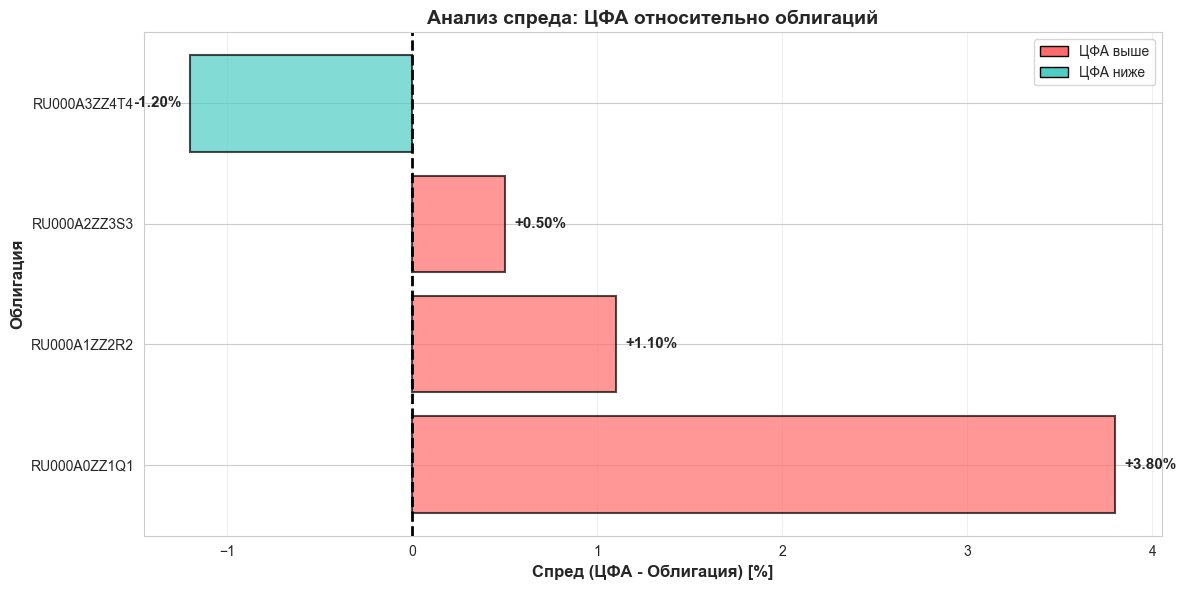


📊 АНАЛИЗ СПРЕДА:
Минимальный спред: -1.20%
Максимальный спред: +3.80%
Средний спред: +1.05%
Стд. отклонение: 1.80%


In [10]:
# Визуализация спреда
fig, ax = plt.subplots(figsize=(12, 6))

spreads = primary_comparison['absolute_spread_pct'].tolist()
bond_names = primary_comparison['bond_secid'].tolist()

# Цвета в зависимости от знака спреда
colors = ['#FF6B6B' if s > 0 else '#4ECDC4' for s in spreads]

# Горизонтальный bar chart
bars = ax.barh(range(len(spreads)), spreads, color=colors, 
              alpha=0.7, edgecolor='black', linewidth=1.5)

# Вертикальная линия на нуле
ax.axvline(x=0, color='black', linestyle='--', linewidth=2)

# Добавление значений
for bar, spread in zip(bars, spreads):
    width = bar.get_width()
    ax.text(width + (0.05 if width > 0 else -0.05), 
           bar.get_y() + bar.get_height()/2,
           f'{spread:+.2f}%',
           ha='left' if width > 0 else 'right', 
           va='center', fontsize=11, fontweight='bold')

# Настройка
ax.set_xlabel('Спред (ЦФА - Облигация) [%]', fontsize=12, fontweight='bold')
ax.set_ylabel('Облигация', fontsize=12, fontweight='bold')
ax.set_title('Анализ спреда: ЦФА относительно облигаций', fontsize=14, fontweight='bold')
ax.set_yticks(range(len(bond_names)))
ax.set_yticklabels(bond_names)
ax.grid(axis='x', alpha=0.3)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF6B6B', edgecolor='black', label='ЦФА выше'),
                  Patch(facecolor='#4ECDC4', edgecolor='black', label='ЦФА ниже')]
ax.legend(handles=legend_elements, loc='best', fontsize=10)

plt.tight_layout()
plt.show()

print("\n📊 АНАЛИЗ СПРЕДА:")
print(f"Минимальный спред: {min(spreads):+.2f}%")
print(f"Максимальный спред: {max(spreads):+.2f}%")
print(f"Средний спред: {np.mean(spreads):+.2f}%")
print(f"Стд. отклонение: {np.std(spreads):.2f}%")

## ⚡ 11. Профиль риск-доходность

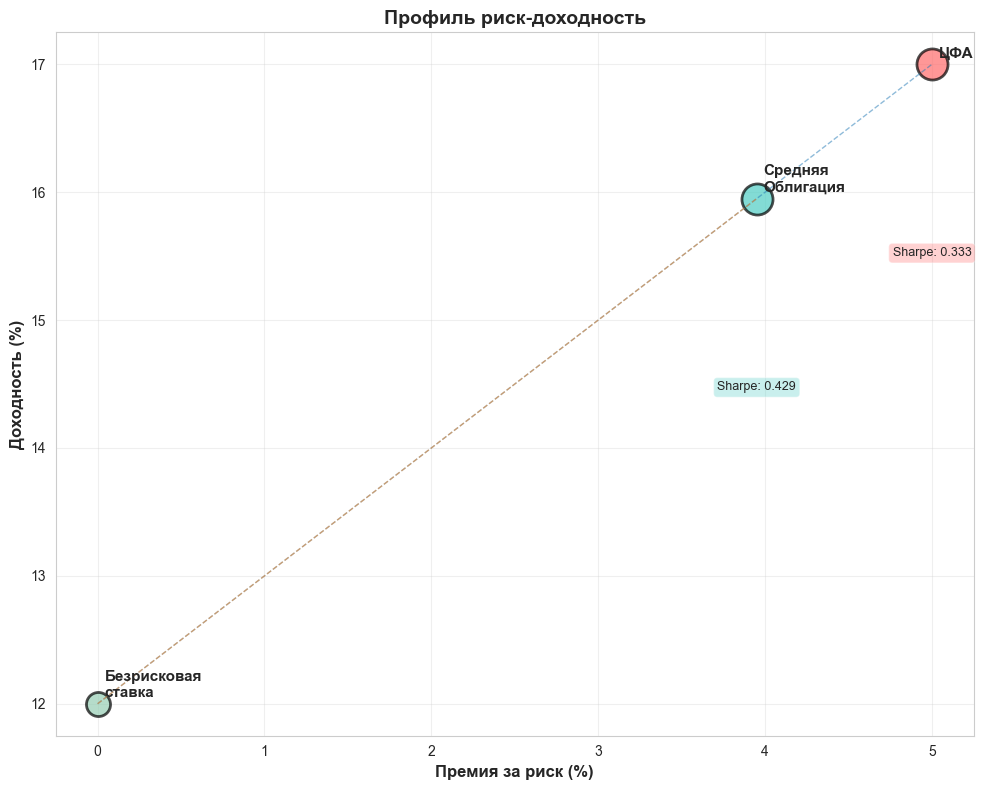


⚡ ПРОФИЛЬ РИСК-ДОХОДНОСТЬ:

ЦФА:
  Доходность: 17.00%
  Риск: 5.00%
  Sharpe: 0.333

Облигации (средние):
  Доходность: 15.95%
  Риск: 3.95%
  Sharpe: 0.429

✅ Облигации показывают лучшую эффективность по Sharpe


In [11]:
# Получение данных риск-доходность
risk_return_profile = comparator.analyze_risk_return_profile()

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))

# Данные
instruments = ['ЦФА', 'Средняя\nОблигация', 'Безрисковая\nставка']
returns = [
    dfa_summary['yield_metrics']['nominal_yield_pct'],
    bonds_summary['yield_stats']['mean_ytm'],
    ANALYSIS_CONFIG['risk_free_rate']
]
risks = [
    dfa_summary['risk_metrics']['risk_premium'],
    bonds_summary['risk_stats']['mean_risk_premium'],
    0
]
sizes = [500, 500, 300]
colors = ['#FF6B6B', '#4ECDC4', '#96CEB4']

# Scatter plot
for i, (instrument, ret, risk, size, color) in enumerate(zip(instruments, returns, risks, sizes, colors)):
    ax.scatter(risk, ret, s=size, alpha=0.7, color=color, 
               edgecolors='black', linewidth=2)
    ax.annotate(instrument, (risk, ret),
               xytext=(5, 5), textcoords='offset points',
               fontsize=11, fontweight='bold')

# Добавление линий от безрисковой ставки
for i in range(2):
    ax.plot([0, risks[i]], [ANALYSIS_CONFIG['risk_free_rate'], returns[i]],
            '--', alpha=0.5, linewidth=1)

# Настройка
ax.set_xlabel('Премия за риск (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Доходность (%)', fontsize=12, fontweight='bold')
ax.set_title('Профиль риск-доходность', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Добавление аннотаций Sharpe ratio
dfa_sharpe = dfa_summary['risk_metrics']['sharpe_ratio']
bond_sharpe = bonds_summary['risk_stats']['mean_sharpe']

ax.text(risks[0], returns[0] - 1.5, f"Sharpe: {dfa_sharpe:.3f}",
       ha='center', fontsize=9, 
       bbox=dict(boxstyle='round,pad=0.3', facecolor='#FF6B6B', alpha=0.3))
ax.text(risks[1], returns[1] - 1.5, f"Sharpe: {bond_sharpe:.3f}",
       ha='center', fontsize=9,
       bbox=dict(boxstyle='round,pad=0.3', facecolor='#4ECDC4', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n⚡ ПРОФИЛЬ РИСК-ДОХОДНОСТЬ:")
print(f"\nЦФА:")
print(f"  Доходность: {returns[0]:.2f}%")
print(f"  Риск: {risks[0]:.2f}%")
print(f"  Sharpe: {dfa_sharpe:.3f}")

print(f"\nОблигации (средние):")
print(f"  Доходность: {returns[1]:.2f}%")
print(f"  Риск: {risks[1]:.2f}%")
print(f"  Sharpe: {bond_sharpe:.3f}")

if dfa_sharpe > bond_sharpe:
    print("\n✅ ЦФА показывает лучшую эффективность по Sharpe")
else:
    print("\n✅ Облигации показывают лучшую эффективность по Sharpe")

## 🔍 12. Декомпозиция спреда


🔍 ДЕКОМПОЗИЦИЯ СПРЕДА НА ФАКТОРЫ:
🔴 Liquidity Component: +1.11%
🟢 Credit Component: +0.00%
🔴 Technology Component: +0.50%
🔴 Regulatory Component: +0.30%

📊 Необъясненный остаток: -0.86%


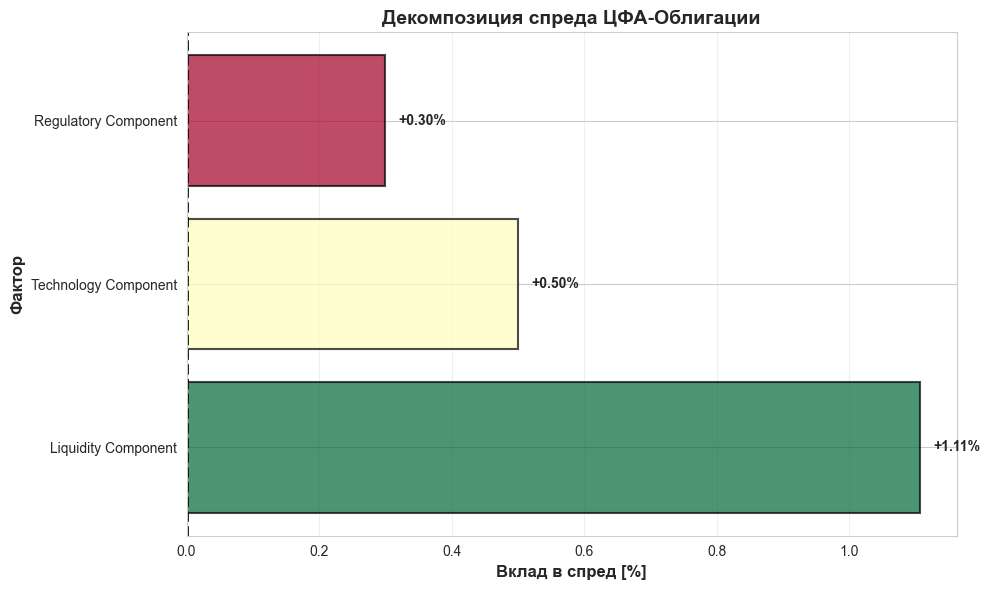

In [12]:
# Анализ факторов спреда
spread_drivers = comparator.identify_spread_drivers()

print("\n🔍 ДЕКОМПОЗИЦИЯ СПРЕДА НА ФАКТОРЫ:")
print("=" * 60)

for driver, value in spread_drivers.items():
    if driver not in ['total_spread', 'unexplained']:
        icon = "🔴" if value > 0 else "🟢"
        print(f"{icon} {driver.replace('_', ' ').title()}: {value:+.2f}%")

print(f"\n📊 Необъясненный остаток: {spread_drivers['unexplained']:+.2f}%")
print("=" * 60)

# Визуализация декомпозиции
fig, ax = plt.subplots(figsize=(10, 6))

# Подготовка данных (исключая total_spread и unexplained)
plot_drivers = {k: v for k, v in spread_drivers.items() 
                if k not in ['total_spread', 'unexplained'] and v != 0}

driver_names = [name.replace('_', ' ').title() for name in plot_drivers.keys()]
driver_values = list(plot_drivers.values())

if len(driver_values) > 0:
    colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(driver_values)))
    
    bars = ax.barh(range(len(driver_values)), driver_values,
                  color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Вертикальная линия
    ax.axvline(x=0, color='black', linestyle='--', linewidth=2)
    
    # Значения
    for bar, value in zip(bars, driver_values):
        width = bar.get_width()
        ax.text(width + (0.02 if width > 0 else -0.02),
               bar.get_y() + bar.get_height()/2,
               f'{value:+.2f}%',
               ha='left' if width > 0 else 'right',
               va='center', fontsize=10, fontweight='bold')
    
    # Настройка
    ax.set_xlabel('Вклад в спред [%]', fontsize=12, fontweight='bold')
    ax.set_ylabel('Фактор', fontsize=12, fontweight='bold')
    ax.set_title('Декомпозиция спреда ЦФА-Облигации', fontsize=14, fontweight='bold')
    ax.set_yticks(range(len(driver_names)))
    ax.set_yticklabels(driver_names)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 🎯 13. Инвестиционные рекомендации

In [13]:
# Генерация рекомендаций
recommendation = comparator.generate_investment_recommendation()

print("\n" + "=" * 70)
print("🎯 ИНВЕСТИЦИОННЫЕ РЕКОМЕНДАЦИИ")
print("=" * 70)

print(f"\n📊 ОБЩАЯ РЕКОМЕНДАЦИЯ: {recommendation['overall_recommendation'].upper()}")
print(f"\nОбоснование: {recommendation['reasoning']}")

print(f"\n📈 КЛЮЧЕВЫЕ ФАКТОРЫ:")
key_factors = recommendation['key_factors']
print(f"  • Преимущество в доходности: {key_factors['yield_advantage']:+.2f}%")
print(f"  • Преимущество в Sharpe: {key_factors['sharpe_advantage']:+.3f}")
print(f"  • Дисконт за ликвидность: {key_factors['liquidity_disadvantage']:+.2f}%")

print(f"\n👤 РЕКОМЕНДАЦИИ ДЛЯ РАЗЛИЧНЫХ ИНВЕСТОРОВ:")
for profile, advice in recommendation['investor_suggestions'].items():
    print(f"\n  {profile.upper()} ИНВЕСТОР:")
    print(f"    Выбор: {advice['preferred']}")
    print(f"    Обоснование: {advice['reason']}")

print("\n" + "=" * 70)


🎯 ИНВЕСТИЦИОННЫЕ РЕКОМЕНДАЦИИ

📊 ОБЩАЯ РЕКОМЕНДАЦИЯ: BONDS

Обоснование: Bonds offer better risk-adjusted returns

📈 КЛЮЧЕВЫЕ ФАКТОРЫ:
  • Преимущество в доходности: +1.05%
  • Преимущество в Sharpe: -0.096
  • Дисконт за ликвидность: +1.11%

👤 РЕКОМЕНДАЦИИ ДЛЯ РАЗЛИЧНЫХ ИНВЕСТОРОВ:

  CONSERVATIVE ИНВЕСТОР:
    Выбор: Bonds
    Обоснование: Higher liquidity, established market, lower regulatory risk

  BALANCED ИНВЕСТОР:
    Выбор: Bonds
    Обоснование: Bonds offer better risk-adjusted returns

  AGGRESSIVE ИНВЕСТОР:
    Выбор: DFA
    Обоснование: Higher yield potential, diversification benefit



## 📊 14. Сводная таблица сравнения

In [14]:
# Создание сводной таблицы
summary_data = {
    'Показатель': [
        'Доходность номинальная (%)',
        'Доходность после налога (%)',
        'Срок обращения (мес)',
        'Премия за риск (%)',
        'Sharpe Ratio',
        'Мин. сумма инвестиции (₽)',
        'Ликвидность',
        'Риски'
    ],
    'ЦФА': [
        f"{dfa_summary['yield_metrics']['nominal_yield_pct']:.2f}",
        f"{dfa_summary['yield_metrics']['after_tax_yield_pct']:.2f}",
        f"{dfa_summary['time_metrics']['years_to_maturity']*12:.0f}",
        f"{dfa_summary['risk_metrics']['risk_premium']:.2f}",
        f"{dfa_summary['risk_metrics']['sharpe_ratio']:.3f}",
        f"{DFA_PARAMS['min_investment']:,.0f}",
        'Низкая',
        'Высокие (технология, регуляция)'
    ],
    'Облигации (средние)': [
        f"{bonds_summary['yield_stats']['mean_ytm']:.2f}",
        f"{bonds_summary['after_tax_stats']['mean_after_tax']:.2f}",
        '12',
        f"{bonds_summary['risk_stats']['mean_risk_premium']:.2f}",
        f"{bonds_summary['risk_stats']['mean_sharpe']:.3f}",
        '1,000 - 100,000',
        'Высокая',
        'Средние (кредитный, процентный)'
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n📊 СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ")
print("=" * 100)
print(summary_df.to_string(index=False))
print("=" * 100)


📊 СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ
                 Показатель                             ЦФА             Облигации (средние)
 Доходность номинальная (%)                           17.00                           15.95
Доходность после налога (%)                           14.79                           13.05
       Срок обращения (мес)                              13                              12
         Премия за риск (%)                            5.00                            3.95
               Sharpe Ratio                           0.333                           0.429
  Мин. сумма инвестиции (₽)                           1,000                 1,000 - 100,000
                Ликвидность                          Низкая                         Высокая
                      Риски Высокие (технология, регуляция) Средние (кредитный, процентный)


## ✅ 15. Заключение и выводы

In [15]:
print("\n" + "=" * 70)
print("✅ ЗАКЛЮЧЕНИЕ И ВЫВОДЫ")
print("=" * 70)

# Ключевые метрики
dfa_yield = dfa_summary['yield_metrics']['nominal_yield_pct']
avg_bond_yield = bonds_summary['yield_stats']['mean_ytm']
spread = dfa_yield - avg_bond_yield
dfa_sharpe = dfa_summary['risk_metrics']['sharpe_ratio']
avg_bond_sharpe = bonds_summary['risk_stats']['mean_sharpe']

print("\n📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:")
print("-" * 50)

print(f"\n1. ДОХОДНОСТЬ:")
if abs(spread) < 0.5:
    print(f"   ✅ Спред минимальный ({spread:+.2f}%) - доходности сопоставимы")
elif spread > 0:
    print(f"   📈 ЦФА превосходит облигации на {spread:.2f}%")
else:
    print(f"   📉 Облигации превосходят ЦФА на {abs(spread):.2f}%")

print(f"\n2. ЭФФЕКТИВНОСТЬ (Sharpe Ratio):")
if dfa_sharpe > avg_bond_sharpe:
    print(f"   ✅ ЦФА: {dfa_sharpe:.3f} > Облигации: {avg_bond_sharpe:.3f}")
    print(f"   💡 Лучший риск-скорректированный доход")
else:
    print(f"   ✅ Облигации: {avg_bond_sharpe:.3f} > ЦФА: {dfa_sharpe:.3f}")
    print(f"   💡 Лучший риск-скорректированный доход")

print(f"\n3. ЛИКВИДНОСТЬ:")
print(f"   ✅ Облигации: Высокая ликвидность (биржевой рынок)")
print(f"   ⚠️ ЦФА: Низкая ликвидность (ограниченный рынок)")
print(f"   💡 Премия за ликвидность: {ANALYSIS_CONFIG['liquidity_discount_bonds']:.1f}%")

print(f"\n4. РИСКИ:")
print(f"   Общие: кредитный риск, процентный риск")
print(f"   ЦФА-специфичные: технологические, регуляторные")
print(f"   Облигации: рыночные, инфляционные")

print(f"\n" + "=" * 70)
print("🎯 ИТОГОВАЯ РЕКОМЕНДАЦИЯ:")
print("=" * 70)

print("\n✅ Для КОНСЕРВАТИВНЫХ инвесторов:")
print("   → Выбирайте ОБЛИГАЦИИ")
print("   ✓ Высокая ликвидность")
print("   ✓ Прозрачное регулирование")
print("   ✓ Биржевая торговля")

print("\n✅ Для АГРЕССИВНЫХ инвесторов:")
print("   → Рассмотрите ЦФА")
print("   ✓ Потенциально более высокая доходность")
print("   ✓ Диверсификация портфеля")
print("   ✓ Доступ к инновационным инструментам")

print("\n✅ Для СБАЛАНСИРОВАННЫХ инвесторов:")
print("   → Диверсификация: ЦФА + Облигации")
print("   ✓ Баланс риска и доходности")
print("   ✓ Различные профильные характеристики")

print("\n" + "=" * 70)
print("✅ АНАЛИЗ ЗАВЕРШЕН")
print("=" * 70)


✅ ЗАКЛЮЧЕНИЕ И ВЫВОДЫ

📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:
--------------------------------------------------

1. ДОХОДНОСТЬ:
   📈 ЦФА превосходит облигации на 1.05%

2. ЭФФЕКТИВНОСТЬ (Sharpe Ratio):
   ✅ Облигации: 0.429 > ЦФА: 0.333
   💡 Лучший риск-скорректированный доход

3. ЛИКВИДНОСТЬ:
   ✅ Облигации: Высокая ликвидность (биржевой рынок)
   ⚠️ ЦФА: Низкая ликвидность (ограниченный рынок)
   💡 Премия за ликвидность: 0.5%

4. РИСКИ:
   Общие: кредитный риск, процентный риск
   ЦФА-специфичные: технологические, регуляторные
   Облигации: рыночные, инфляционные

🎯 ИТОГОВАЯ РЕКОМЕНДАЦИЯ:

✅ Для КОНСЕРВАТИВНЫХ инвесторов:
   → Выбирайте ОБЛИГАЦИИ
   ✓ Высокая ликвидность
   ✓ Прозрачное регулирование
   ✓ Биржевая торговля

✅ Для АГРЕССИВНЫХ инвесторов:
   → Рассмотрите ЦФА
   ✓ Потенциально более высокая доходность
   ✓ Диверсификация портфеля
   ✓ Доступ к инновационным инструментам

✅ Для СБАЛАНСИРОВАННЫХ инвесторов:
   → Диверсификация: ЦФА + Облигации
   ✓ Баланс риска и доходности
   ✓ Разли